# Estimativas de Localização

## Objetivos da aula
- Aprender o básico do Jupyter
- Calcular e interpretar **média** e **mediana**
- Entender **robustez** (sensibilidade a outliers)
- Identificar **outliers** e ver o seu impacto nas estimativas

## Jupyter em 9 comandos
- `Shift + Enter`: executa a célula e vai para a próxima
- `Ctrl + Enter`:  executa a célula e fica na mesma célula
- `A` (no modo comando): cria célula acima
- `B` (no modo comando): cria célula abaixo
- `M`/`Y`: muda a célula para Markdown / Code
- `DD`: apaga a célula
- `Z`: desfaz a ultima ação
- `C`: copia a célula
- `V`: cola a célula copiada

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dados = np.array([10, 11, 10, 12, 11, 10, 13, 12, 11, 10, 12, 11])

dados

array([10, 11, 10, 12, 11, 10, 13, 12, 11, 10, 12, 11])

In [4]:
pd.Series(dados).describe()

count    12.000000
mean     11.083333
std       0.996205
min      10.000000
25%      10.000000
50%      11.000000
75%      12.000000
max      13.000000
dtype: float64

In [5]:
from scipy import stats

In [6]:
media = dados.mean()
mediana = np.median(dados)
moda = stats.mode(dados)

media, mediana, moda

(11.083333333333334, 11.0, ModeResult(mode=10, count=4))

### Interpretação
- **Média**: "puxa" o centro levando em consideração o todo;
- **Mediana**: valor central da lista ordenada (mais resistente aos extremos).

_Quando os dados são simétricos e sem extremos, média é aproximdamente igual à mediana._

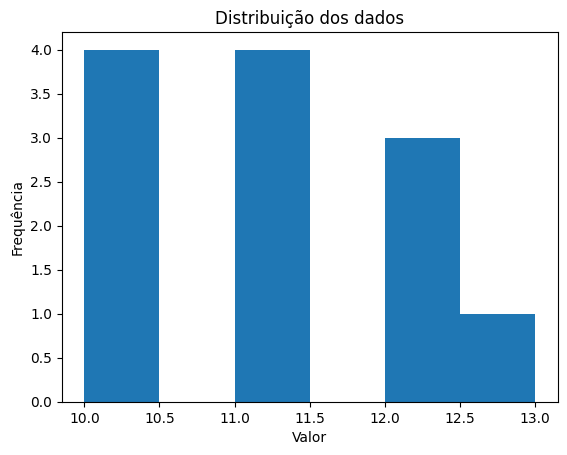

In [7]:
plt.figure()
plt.hist(dados, bins=6)
plt.title("Distribuição dos dados")
plt.xlabel("Valor")
plt.ylabel("Frequência")
plt.show()

In [8]:
dados_com_outlier = np.append(dados, 80)
media2 = dados_com_outlier.mean()
mediana2 = np.median(dados_com_outlier)

media2, mediana2

(16.384615384615383, 11.0)

In [9]:
pd.Series(dados_com_outlier).describe()

count    13.000000
mean     16.384615
std      19.137827
min      10.000000
25%      10.000000
50%      11.000000
75%      12.000000
max      80.000000
dtype: float64

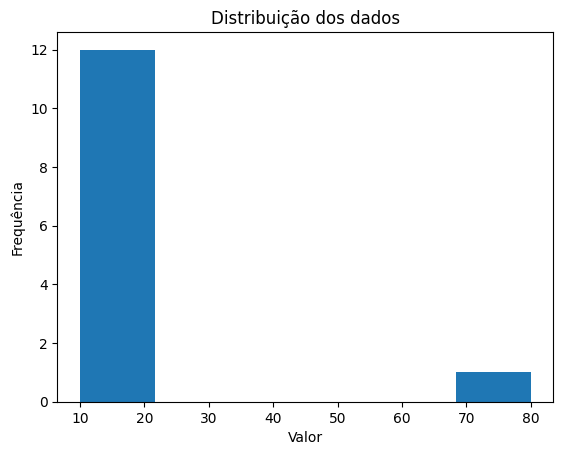

In [10]:
plt.figure()
plt.hist(dados_com_outlier, bins=6)
plt.title("Distribuição dos dados")
plt.xlabel("Valor")
plt.ylabel("Frequência")
plt.show()

## Robustez
Uma medida é **robusta** quando **não muda muito** na presença de valores extremos (outliers).

Compare:
- A média muda bastante com o outlier.
- A mediana tende a mudar pouco (ou nem muda), por isso é mais robusta.

In [11]:
s = pd.Series(dados_com_outlier)

q1 = s.quantile(0.25) # Primeiro Quartil
q3 = s.quantile(0.75) # Terceiro Quartil
iqr = q3 - q1 # Distância Interquartil

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

q1, q3, iqr, limite_inferior, limite_superior

(10.0, 12.0, 2.0, 7.0, 15.0)

In [12]:
outliers = s[(s < limite_inferior) | (s > limite_superior)]
outliers

12    80
dtype: int32

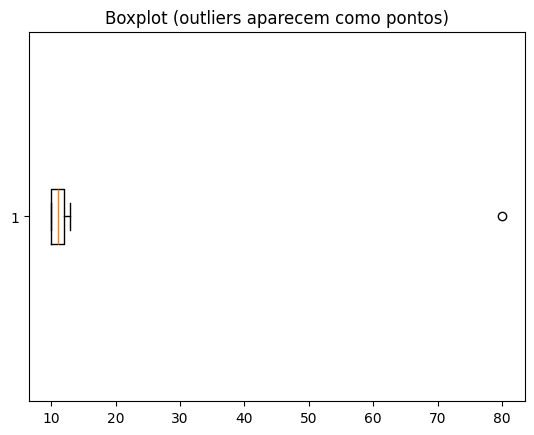

In [13]:
plt.figure()
plt.boxplot(s, vert=False)
plt.title("Boxplot (outliers aparecem como pontos)")
plt.show()

## Robustez
Uma medida é **robusta** quando **não muda muito** na presença de valores extremos (outliers).

Compare:
- A média muda bastante com o outlier.
- A mediana tende a mudar pouco (ou nem muda), por isso é mais robusta.

## Outlier
Outlier é um valor **muito distante** do padrão dos dados.
Ele pode ocorrer por:
- erro de coleta/registro
- caso raro real (evento extremo)
- mudança de comportamento do processo

Importante: outlier **não é automaticamente “erro”** — depende do contexto.

## Resumo do que você precisa guardar
- **Média**: excelente em dados “limpos”, mas **sensível a outliers**
- **Mediana**: excelente para dados com extremos, **mais robusta**
- **Robustez**: pouca sensibilidade a valores extremos/anômalos
- **Outlier**: valor anômalo; exige investigação e contexto

#### Exercício 1 — média vs mediana (código)

In [ ]:
x = np.array([20, 21, 22, 22, 23, 23, 24, 25])

# TODO:
# 1) calcule média e mediana
# 2) adicione um outlier (ex: 120) e recalcule
# 3) descreva (em Markdown) o que mudou e por quê

#### Exercício 2 — detectando outliers por IQR (código)

In [ ]:
y = pd.Series([5, 6, 5, 7, 6, 5, 6, 7, 6, 5, 50])

# TODO:
# 1) calcule Q1, Q3, IQR
# 2) calcule limites inferior e superior (1.5*IQR)
# 3) liste os outliers encontrados

#### Exercício 3 — mini-desafio (interpretação + gráfico)

In [ ]:
z = pd.Series([100, 102, 98, 101, 99, 100, 97, 103, 100, 500])

# TODO:
# 1) faça um histograma e um boxplot
# 2) compare média e mediana
# 3) responda: qual medida representa melhor o “típico” aqui? Justifique robustez.

#### Exercício 4 — “contexto real” (opcional, legal pra engajar)

In [ ]:
# Imagine que isso é o tempo (em segundos) de resposta de um endpoint:
latencia = pd.Series([120, 130, 125, 140, 128, 132, 127, 129, 800, 135, 131])

# TODO:
# 1) calcule média, mediana
# 2) detecte outliers por IQR
# 3) escreva: se você fosse reportar UMA métrica para o time de produto, qual escolheria e por quê?